# Voice Command AI — Training Pipeline
**Proyecto 1 — IA I-2026 | TEC Costa Rica**

Pipeline completo:
1. Dataset — Google Speech Commands v2
2. Preprocesamiento — Mel Spectrogram (64×101)
3. SpecAugment (Park et al. 2019)
4. Modelo A — LeNet-5 adaptado
5. Modelo B — MobileNetV3-Small adaptado
6. 12 runs WandB (3 por combinación)
7. Exportación ONNX (opset 17)
8. Validación numérica ONNX vs PyTorch

In [ ]:
# ── Instalar dependencias ────────────────────────────────────────────────────
%pip install torch torchaudio torchvision wandb onnx onnxscript onnxruntime scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import wandb
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from collections import Counter

# ── WandB login ─────────────────────────────────────────────────────────────
wandb.login(key="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")

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adbyb-es (ai-allan-david) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: cuda


## 1. Dataset — Speech Commands v2

In [ ]:
# ── Constantes ──────────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 160
TARGET_LEN = 16000  # 1 segundo

# 10 comandos según enunciado (Tabla I)
TARGET_CLASSES = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)  # 10

# torchaudio descarga a data/SpeechCommands/speech_commands_v0.02/
DATA_DIR = Path('data/SpeechCommands/speech_commands_v0.02')

if not DATA_DIR.exists():
    print('Descargando Speech Commands v2 (~2.3 GB)...')
    Path('data/').mkdir(parents=True, exist_ok=True)
    torchaudio.datasets.SPEECHCOMMANDS(root='data/', download=True, subset='training')
    print('Dataset descargado.')
else:
    print('Dataset ya existe.')


Descargando Speech Commands v2 (~2.3 GB)...


100%|██████████| 2.26G/2.26G [00:09<00:00, 246MB/s]


Dataset descargado.


In [ ]:
# ── Transformaciones ────────────────────────────────────────────────────────
mel_transform = nn.Sequential(
    T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_min=20.0,
        f_max=8000.0,
    ),
    T.AmplitudeToDB(),
)

def pad_or_trim(waveform, target_len=TARGET_LEN):
    if waveform.shape[-1] < target_len:
        waveform = F.pad(waveform, (0, target_len - waveform.shape[-1]))
    else:
        waveform = waveform[..., :target_len]
    return waveform

def to_spectrogram(waveform):
    waveform = pad_or_trim(waveform)
    spec = mel_transform(waveform)  # [1, 64, 101]
    return spec

# Calcular estadísticas de normalización en el set de entrenamiento
def compute_norm_stats(dataset, n_samples=2000):
    specs = []
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    for i in indices:
        waveform, sr, label, *_ = dataset[i]
        if label in TARGET_CLASSES:
            spec = to_spectrogram(waveform)
            specs.append(spec)
    data = torch.stack(specs)
    mean = data.mean().item()
    std = data.std().item()
    return mean, std

print('Calculando estadísticas de normalización...')
train_dataset_raw = torchaudio.datasets.SPEECHCOMMANDS('data/', subset='training')
NORM_MEAN, NORM_STD = compute_norm_stats(train_dataset_raw)
print(f'mean={NORM_MEAN:.4f}, std={NORM_STD:.4f}')

# Guardar norm_stats.json (en Colab queda en /content/norm_stats.json)
with open('norm_stats.json', 'w') as f:
    json.dump({'mean': NORM_MEAN, 'std': NORM_STD}, f, indent=2)
print('norm_stats.json guardado.')


Calculando estadísticas de normalización...
mean=-24.4861, std=23.0680
norm_stats.json guardado.


In [ ]:
# ── Dataset PyTorch ──────────────────────────────────────────────────────────
class SpeechCommandsDataset(Dataset):
    def __init__(self, subset, augment=False, norm_mean=NORM_MEAN, norm_std=NORM_STD):
        self.data = torchaudio.datasets.SPEECHCOMMANDS('data/', subset=subset)
        self.augment = augment
        self.norm_mean = norm_mean
        self.norm_std = norm_std
        # Filtrar: clases target solamente
        self.samples = [
            (waveform, sr, label)
            for waveform, sr, label, *_ in self.data
            if label in TARGET_CLASSES
        ]
        # SpecAugment transforms
        self.time_mask = T.TimeMasking(time_mask_param=40)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=27)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        waveform, sr, label = self.samples[idx]
        spec = to_spectrogram(waveform)  # [1, 64, 101]
        # Normalize
        spec = (spec - self.norm_mean) / (self.norm_std + 1e-8)
        # SpecAugment (Park et al. 2019)
        if self.augment:
            spec = self.time_mask(spec)
            spec = self.freq_mask(spec)
        return spec, CLASS_TO_IDX[label]

# Crear datasets
train_base = SpeechCommandsDataset('training', augment=False)
train_aug  = SpeechCommandsDataset('training', augment=True)
val_ds     = SpeechCommandsDataset('validation', augment=False)
test_ds    = SpeechCommandsDataset('testing', augment=False)

print(f'Train: {len(train_base)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# DataLoaders
BATCH_SIZE = 64
train_base_loader = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
train_aug_loader  = DataLoader(train_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader        = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader       = DataLoader(test_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 30769 | Val: 3703 | Test: 4074


## 2. Modelo A — LeNet-5 adaptado
Entrada: `[batch, 1, 64, 101]`

`Conv2d(1,6,5,pad=2) → AvgPool(2,2) → Conv2d(6,16,5) → AvgPool(2,2) → Flatten → Linear→120 → Linear→84 → Linear→12`

In [ ]:
class LeNet5KWS(nn.Module):
    """LeNet-5 adaptado para KWS (entrada 1×64×101, 12 clases)"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        # Calcular tamaño dinámico
        dummy = torch.zeros(1, 1, 64, 101)
        feat_size = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_size, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Verificar arquitectura
model_a = LeNet5KWS().to(DEVICE)
dummy = torch.zeros(1, 1, 64, 101).to(DEVICE)
out = model_a(dummy)
print(f'LeNet-5 output shape: {out.shape}')  # esperado: [1, 12]
total_params = sum(p.numel() for p in model_a.parameters())
print(f'Parámetros totales: {total_params:,}')

LeNet-5 output shape: torch.Size([1, 10])
Parámetros totales: 631,946


## 3. Modelo B — MobileNetV3-Small adaptado
Primer conv modificado para entrada 1 canal. Justificación: ~2.5M params, diseñado para móvil.

In [ ]:
import torchvision.models as models

def build_mobilenet_v3_kws(num_classes=NUM_CLASSES):
    """MobileNetV3-Small con primer conv adaptado a 1 canal"""
    model = models.mobilenet_v3_small(weights=None)
    # Modificar primer conv: (3,16,3,stride=2) → (1,16,3,stride=2)
    model.features[0][0] = nn.Conv2d(
        in_channels=1, out_channels=16,
        kernel_size=3, stride=2, padding=1, bias=False
    )
    # Modificar cabeza clasificadora para 12 clases
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    return model

model_b = build_mobilenet_v3_kws().to(DEVICE)
out = model_b(dummy)
print(f'MobileNetV3 output shape: {out.shape}')  # esperado: [1, 12]
total_params = sum(p.numel() for p in model_b.parameters())
print(f'Parámetros totales: {total_params:,}')

MobileNetV3 output shape: torch.Size([1, 10])
Parámetros totales: 1,527,818


## 4. Training Loop + WandB

12 runs mínimo:
- **A1-A3**: LeNet-5, dataset base, LR variado
- **A4-A6**: LeNet-5, dataset aumentado, LR/batch variado
- **B1-B3**: MobileNetV3, dataset base, LR variado
- **B4-B6**: MobileNetV3, dataset aumentado

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for specs, labels in loader:
        specs, labels = specs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(specs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * specs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += specs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for specs, labels in loader:
        specs, labels = specs.to(DEVICE), labels.to(DEVICE)
        logits = model(specs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * specs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += specs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1, all_preds, all_labels


def run_training(run_name, model_fn, loader, epochs=30, lr=1e-3,
                 optimizer_cls=torch.optim.Adam, scheduler_fn=None, weight_decay=1e-4):
    """Ejecuta un run de entrenamiento con WandB logging."""
    wandb.init(project='voice-command-ai', name=run_name,
               config={'lr': lr, 'epochs': epochs, 'optimizer': optimizer_cls.__name__,
                       'weight_decay': weight_decay})

    model = model_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    best_f1 = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, criterion)

        if scheduler:
            scheduler.step()

        wandb.log({
            'epoch': epoch,
            'train/loss': train_loss, 'train/acc': train_acc,
            'val/loss': val_loss,   'val/acc': val_acc,
            'val/f1_macro': val_f1,
        })

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0:
            print(f'[{run_name}] Epoch {epoch:3d} | '
                  f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}')

    # Cargar el mejor checkpoint y evaluar en test
    model.load_state_dict(best_state)
    _, test_acc, test_f1, test_preds, test_labels = eval_epoch(model, test_loader, criterion)

    # Log confusion matrix
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=TARGET_CLASSES,
                yticklabels=TARGET_CLASSES, ax=ax)
    ax.set_title(f'{run_name} — Confusion Matrix (test)')
    wandb.log({'test/confusion_matrix': wandb.Image(fig),
               'test/acc': test_acc, 'test/f1_macro': test_f1})
    plt.close(fig)

    print(f'[{run_name}] BEST val_f1={best_f1:.4f} | test_acc={test_acc:.4f} test_f1={test_f1:.4f}')
    wandb.finish()
    return model, best_f1, test_f1

In [ ]:
# ── Runs A1-A3: LeNet-5, dataset base ─────────────────────────────────────
results = {}

for run_id, lr in [('A1', 0.01), ('A2', 0.001), ('A3', 0.0001)]:
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=LeNet5KWS,
        loader=train_base_loader,
        lr=lr,
        optimizer_cls=torch.optim.SGD,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

[A1] Epoch   5 | val_loss=1.0180 val_acc=0.6641 val_f1=0.6653
[A1] Epoch  10 | val_loss=0.6367 val_acc=0.7977 val_f1=0.7979
[A1] Epoch  15 | val_loss=0.5025 val_acc=0.8361 val_f1=0.8362
[A1] Epoch  20 | val_loss=0.4836 val_acc=0.8372 val_f1=0.8382
[A1] Epoch  25 | val_loss=0.4359 val_acc=0.8520 val_f1=0.8522
[A1] Epoch  30 | val_loss=0.4238 val_acc=0.8620 val_f1=0.8625
[A1] BEST val_f1=0.8638 | test_acc=0.8562 test_f1=0.8559


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train/loss,█▇▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▆▆▇▇▇▇▇▇▇███▇████████████
val/f1_macro,▁▃▄▅▅▆▆▇▇▇▇▇█▇████████████████
val/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.85616
test/f1_macro,0.85592


[A2] Epoch   5 | val_loss=2.0335 val_acc=0.2925 val_f1=0.2476
[A2] Epoch  10 | val_loss=1.8417 val_acc=0.3584 val_f1=0.3195
[A2] Epoch  15 | val_loss=1.6646 val_acc=0.4407 val_f1=0.4225
[A2] Epoch  20 | val_loss=1.5040 val_acc=0.5072 val_f1=0.4940
[A2] Epoch  25 | val_loss=1.3811 val_acc=0.5469 val_f1=0.5361
[A2] Epoch  30 | val_loss=1.2776 val_acc=0.5871 val_f1=0.5794
[A2] BEST val_f1=0.5794 | test_acc=0.5746 test_f1=0.5685


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
train/loss,██▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▁▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
val/f1_macro,▁▁▂▂▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
val/loss,██▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
epoch,30
test/acc,0.57462
test/f1_macro,0.56848


[A3] Epoch   5 | val_loss=2.2982 val_acc=0.1345 val_f1=0.0669
[A3] Epoch  10 | val_loss=2.2906 val_acc=0.1550 val_f1=0.0957
[A3] Epoch  15 | val_loss=2.2806 val_acc=0.1674 val_f1=0.1178
[A3] Epoch  20 | val_loss=2.2668 val_acc=0.1909 val_f1=0.1454
[A3] Epoch  25 | val_loss=2.2487 val_acc=0.2066 val_f1=0.1634
[A3] Epoch  30 | val_loss=2.2265 val_acc=0.2225 val_f1=0.1824
[A3] BEST val_f1=0.1824 | test_acc=0.2278 test_f1=0.1872


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▁▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇███
train/loss,████▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▁▁
val/acc,▁▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇███
val/f1_macro,▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
val/loss,█████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▁▁
epoch,30
test/acc,0.22779
test/f1_macro,0.18719


In [ ]:
# ── Runs A4-A6: LeNet-5, dataset aumentado ────────────────────────────────
for run_id, lr in [('A4', 0.01), ('A5', 0.001), ('A6', 0.0001)]:
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=LeNet5KWS,
        loader=train_aug_loader,
        lr=lr,
        optimizer_cls=torch.optim.SGD,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

[A4] Epoch   5 | val_loss=1.5946 val_acc=0.4910 val_f1=0.4664
[A4] Epoch  10 | val_loss=1.1346 val_acc=0.6319 val_f1=0.6242
[A4] Epoch  15 | val_loss=0.8521 val_acc=0.7140 val_f1=0.7081
[A4] Epoch  20 | val_loss=0.6812 val_acc=0.7723 val_f1=0.7715
[A4] Epoch  25 | val_loss=0.6029 val_acc=0.8029 val_f1=0.8008
[A4] Epoch  30 | val_loss=0.5328 val_acc=0.8177 val_f1=0.8168
[A4] BEST val_f1=0.8168 | test_acc=0.8041 test_f1=0.8036


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▂▂▃▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██████
train/loss,█▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val/acc,▁▂▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█▇███████
val/f1_macro,▁▂▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█▇███████
val/loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,30
test/acc,0.80412
test/f1_macro,0.80355


[A5] Epoch   5 | val_loss=2.1434 val_acc=0.2474 val_f1=0.2018
[A5] Epoch  10 | val_loss=1.9953 val_acc=0.3135 val_f1=0.2831
[A5] Epoch  15 | val_loss=1.9270 val_acc=0.3343 val_f1=0.3064
[A5] Epoch  20 | val_loss=1.8717 val_acc=0.3605 val_f1=0.3348
[A5] Epoch  25 | val_loss=1.8248 val_acc=0.3886 val_f1=0.3671
[A5] Epoch  30 | val_loss=1.7576 val_acc=0.4272 val_f1=0.4093
[A5] BEST val_f1=0.4093 | test_acc=0.3972 test_f1=0.3783


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▂▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████
train/loss,██▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
val/acc,▁▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
val/f1_macro,▁▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
val/loss,██▇▇▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
epoch,30
test/acc,0.39715
test/f1_macro,0.37833


[A6] Epoch   5 | val_loss=2.2965 val_acc=0.1156 val_f1=0.0463
[A6] Epoch  10 | val_loss=2.2888 val_acc=0.1280 val_f1=0.0679
[A6] Epoch  15 | val_loss=2.2800 val_acc=0.1601 val_f1=0.1306
[A6] Epoch  20 | val_loss=2.2696 val_acc=0.1915 val_f1=0.1780
[A6] Epoch  25 | val_loss=2.2571 val_acc=0.2074 val_f1=0.1954
[A6] Epoch  30 | val_loss=2.2423 val_acc=0.2174 val_f1=0.1937
[A6] BEST val_f1=0.1980 | test_acc=0.2177 test_f1=0.1997


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▁▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇█████
train/loss,███▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▁▁
val/acc,▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▅▅▅▆▆▇▇▇▇▇▇████
val/f1_macro,▁▁▁▁▁▁▁▂▂▂▃▃▄▅▅▅▆▆▇▇▇▇████████
val/loss,███▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▁▁
epoch,30
test/acc,0.21772
test/f1_macro,0.19968


In [ ]:
# ── Runs B1-B3: MobileNetV3, dataset base ────────────────────────────────
cos_lr = lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)

for run_id, lr in [('B1', 1e-3), ('B2', 5e-4), ('B3', 1e-3)]:
    wd = 1e-4 if run_id != 'B3' else 5e-4
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=build_mobilenet_v3_kws,
        loader=train_base_loader,
        lr=lr,
        optimizer_cls=torch.optim.Adam,
        scheduler_fn=cos_lr,
        weight_decay=wd,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

[B1] Epoch   5 | val_loss=0.2000 val_acc=0.9379 val_f1=0.9381
[B1] Epoch  10 | val_loss=0.1898 val_acc=0.9365 val_f1=0.9368
[B1] Epoch  15 | val_loss=0.2537 val_acc=0.9419 val_f1=0.9422
[B1] Epoch  20 | val_loss=0.2226 val_acc=0.9500 val_f1=0.9502
[B1] Epoch  25 | val_loss=0.2180 val_acc=0.9522 val_f1=0.9523
[B1] Epoch  30 | val_loss=0.2166 val_acc=0.9549 val_f1=0.9549
[B1] BEST val_f1=0.9563 | test_acc=0.9524 test_f1=0.9524


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▆▆▇▇▇▇▇▇▇▇███████████████████
train/loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇████████████████████████████
val/f1_macro,▁▇████████████████████████████
val/loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.95238
test/f1_macro,0.95238


[B2] Epoch   5 | val_loss=0.2114 val_acc=0.9330 val_f1=0.9338
[B2] Epoch  10 | val_loss=0.2629 val_acc=0.9279 val_f1=0.9287
[B2] Epoch  15 | val_loss=0.2663 val_acc=0.9341 val_f1=0.9340
[B2] Epoch  20 | val_loss=0.2688 val_acc=0.9425 val_f1=0.9428
[B2] Epoch  25 | val_loss=0.2591 val_acc=0.9433 val_f1=0.9435
[B2] Epoch  30 | val_loss=0.2667 val_acc=0.9425 val_f1=0.9426
[B2] BEST val_f1=0.9435 | test_acc=0.9423 test_f1=0.9422


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▆▆▇▇▇▇▇▇█████████████████████
train/loss,█▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁█▇███████████████████████████
val/f1_macro,▁█████████████████████████████
val/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.94232
test/f1_macro,0.94224


[B3] Epoch   5 | val_loss=0.2625 val_acc=0.9236 val_f1=0.9240
[B3] Epoch  10 | val_loss=0.1862 val_acc=0.9379 val_f1=0.9382
[B3] Epoch  15 | val_loss=0.1830 val_acc=0.9376 val_f1=0.9379
[B3] Epoch  20 | val_loss=0.2055 val_acc=0.9452 val_f1=0.9454
[B3] Epoch  25 | val_loss=0.1863 val_acc=0.9487 val_f1=0.9488
[B3] Epoch  30 | val_loss=0.1958 val_acc=0.9465 val_f1=0.9467
[B3] BEST val_f1=0.9488 | test_acc=0.9519 test_f1=0.9520


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▆▆▇▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇████████████████████████████
val/f1_macro,▁▇████████████████████████████
val/loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.95189
test/f1_macro,0.95202


In [ ]:
# ── Runs B4-B6: MobileNetV3, dataset aumentado ───────────────────────────
for run_id, lr in [('B4', 1e-3), ('B5', 5e-4), ('B6', 1e-3)]:
    wd = 1e-4 if run_id != 'B6' else 1e-3
    model, val_f1, test_f1 = run_training(
        run_name=run_id,
        model_fn=build_mobilenet_v3_kws,
        loader=train_aug_loader,
        lr=lr,
        optimizer_cls=torch.optim.Adam,
        scheduler_fn=cos_lr,
        weight_decay=wd,
    )
    results[run_id] = {'model': model, 'val_f1': val_f1, 'test_f1': test_f1}

[B4] Epoch   5 | val_loss=0.2040 val_acc=0.9336 val_f1=0.9345
[B4] Epoch  10 | val_loss=0.1450 val_acc=0.9482 val_f1=0.9486
[B4] Epoch  15 | val_loss=0.1255 val_acc=0.9571 val_f1=0.9572
[B4] Epoch  20 | val_loss=0.1120 val_acc=0.9619 val_f1=0.9620
[B4] Epoch  25 | val_loss=0.1027 val_acc=0.9652 val_f1=0.9653
[B4] Epoch  30 | val_loss=0.0985 val_acc=0.9668 val_f1=0.9668
[B4] BEST val_f1=0.9668 | test_acc=0.9696 test_f1=0.9695


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇████████████████████████████
val/f1_macro,▁▇████████████████████████████
val/loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.96956
test/f1_macro,0.96953


[B5] Epoch   5 | val_loss=0.2353 val_acc=0.9168 val_f1=0.9168
[B5] Epoch  10 | val_loss=0.1924 val_acc=0.9336 val_f1=0.9342
[B5] Epoch  15 | val_loss=0.1503 val_acc=0.9476 val_f1=0.9481
[B5] Epoch  20 | val_loss=0.1461 val_acc=0.9490 val_f1=0.9494
[B5] Epoch  25 | val_loss=0.1348 val_acc=0.9533 val_f1=0.9536
[B5] Epoch  30 | val_loss=0.1338 val_acc=0.9522 val_f1=0.9525
[B5] BEST val_f1=0.9536 | test_acc=0.9556 test_f1=0.9554


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇▇███████████████████████████
val/f1_macro,▁▇▇███████████████████████████
val/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.95557
test/f1_macro,0.95542


[B6] Epoch   5 | val_loss=0.3086 val_acc=0.9066 val_f1=0.9067
[B6] Epoch  10 | val_loss=0.2213 val_acc=0.9271 val_f1=0.9281
[B6] Epoch  15 | val_loss=0.1522 val_acc=0.9509 val_f1=0.9511
[B6] Epoch  20 | val_loss=0.1359 val_acc=0.9522 val_f1=0.9522
[B6] Epoch  25 | val_loss=0.1141 val_acc=0.9587 val_f1=0.9590
[B6] Epoch  30 | val_loss=0.1099 val_acc=0.9603 val_f1=0.9605
[B6] BEST val_f1=0.9611 | test_acc=0.9674 test_f1=0.9672


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/acc,▁
test/f1_macro,▁
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇▇███████████████████████████
val/f1_macro,▁▇▇███████████████████████████
val/loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
test/acc,0.96735
test/f1_macro,0.96724


## 5. Comparación de modelos finalistas

In [ ]:
# Seleccionar mejor de cada grupo
best_a_base = max(['A1','A2','A3'], key=lambda k: results[k]['val_f1'])
best_a_aug  = max(['A4','A5','A6'], key=lambda k: results[k]['val_f1'])
best_b_base = max(['B1','B2','B3'], key=lambda k: results[k]['val_f1'])
best_b_aug  = max(['B4','B5','B6'], key=lambda k: results[k]['val_f1'])

finalists = [best_a_base, best_a_aug, best_b_base, best_b_aug]
print('Finalistas:', finalists)

comparison = {k: results[k]['test_f1'] for k in finalists}
print('Test F1-macro por finalista:')
for k, v in sorted(comparison.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:.4f}')

best_run = max(comparison, key=comparison.get)
best_model = results[best_run]['model']
print(f'\nModelo final: {best_run} (F1={comparison[best_run]:.4f})')

Finalistas: ['A1', 'A4', 'B1', 'B4']
Test F1-macro por finalista:
  B4: 0.9695
  B1: 0.9524
  A1: 0.8559
  A4: 0.8036

Modelo final: B4 (F1=0.9695)


## 6. Exportación ONNX (opset 17)

In [ ]:
ONNX_PATH = Path('kws_model.onnx')

best_model.eval().to('cpu')
dummy_input = torch.randn(1, 1, 64, 101)

torch.onnx.export(
    best_model,
    dummy_input,
    str(ONNX_PATH),
    input_names=['spectrogram'],
    output_names=['logits'],
    dynamic_axes={'spectrogram': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=17,
    dynamo=False,  # exportador TorchScript legacy, compatible con ONNX Runtime Mobile
)

# Verificar modelo ONNX
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
print(f'ONNX exportado y verificado: {ONNX_PATH}')
print(f'Tamaño: {ONNX_PATH.stat().st_size / 1e6:.2f} MB')


/tmp/ipykernel_17420/1412464544.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX exportado y verificado: kws_model.onnx
Tamaño: 6.12 MB


In [ ]:
# ── Validación numérica: PyTorch vs ONNX (100 muestras de test) ──────────
sess = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
criterion = nn.CrossEntropyLoss()

max_diff = 0.0
n_validated = 0

with torch.no_grad():
    for specs, labels in test_loader:
        for i in range(specs.size(0)):
            if n_validated >= 100:
                break
            inp = specs[i:i+1].numpy()
            # PyTorch
            pt_logits = best_model(specs[i:i+1]).softmax(dim=-1).numpy()
            # ONNX
            onnx_logits = sess.run(['logits'], {'spectrogram': inp})[0]
            onnx_prob = torch.from_numpy(onnx_logits).softmax(dim=-1).numpy()
            diff = float(np.abs(pt_logits - onnx_prob).max())
            max_diff = max(max_diff, diff)
            n_validated += 1
        if n_validated >= 100:
            break

print(f'Validación numérica ({n_validated} muestras):')
print(f'  Diferencia máxima softmax: {max_diff:.2e}')
assert max_diff < 1e-5, f'Diferencia demasiado grande: {max_diff}'
print('  ✓ Diferencia < 1e-5 — OK')

Validación numérica (100 muestras):
  Diferencia máxima softmax: 3.43e-07
  ✓ Diferencia < 1e-5 — OK


## 7. Reporte final de clasificación

Test Accuracy: 0.9696
Test F1-macro: 0.9695

              precision    recall  f1-score   support

         yes       0.98      0.99      0.98       419
          no       0.94      0.97      0.95       405
          up       0.96      0.97      0.96       425
        down       0.94      0.95      0.95       406
        left       0.98      0.98      0.98       412
       right       0.99      0.98      0.99       396
          on       0.98      0.96      0.97       396
         off       0.97      0.96      0.97       402
        stop       0.99      0.99      0.99       411
          go       0.97      0.95      0.96       402

    accuracy                           0.97      4074
   macro avg       0.97      0.97      0.97      4074
weighted avg       0.97      0.97      0.97      4074



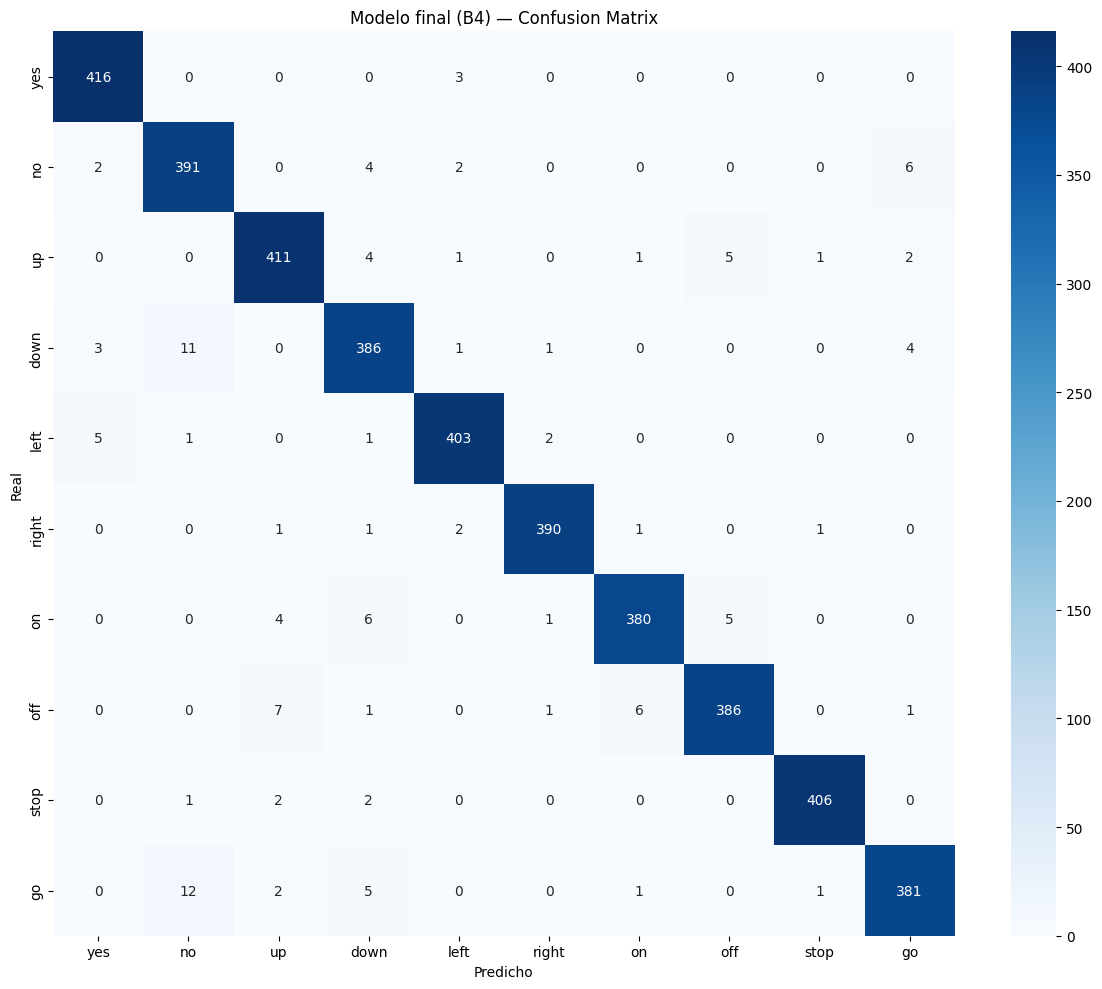

Pipeline completo ✓


In [ ]:
best_model.to(DEVICE)
_, test_acc, test_f1, test_preds, test_labels = eval_epoch(best_model, test_loader, nn.CrossEntropyLoss())

print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1-macro: {test_f1:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=TARGET_CLASSES))

# Confusion matrix final
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Modelo final ({best_run}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()
print('Pipeline completo ✓')

In [ ]:
# ── Descargar archivos desde Colab ──────────────────────────────────────────
# Ejecuta esta celda al final para descargar los 2 archivos que necesita la app
from google.colab import files

print('Descargando kws_model.onnx...')
files.download('kws_model.onnx')

print('Descargando norm_stats.json...')
files.download('norm_stats.json')

print()
print('Coloca ambos archivos en:')
print('  app/assets/models/kws_model.onnx')
print('  app/assets/models/norm_stats.json')


Descargando kws_model.onnx...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando norm_stats.json...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Coloca ambos archivos en:
  app/assets/models/kws_model.onnx
  app/assets/models/norm_stats.json
